# **QR Code & Barcode Detection**

## **Objectives:**
1. Generate a QR code and decode it back with `cv2.QRCodeDetector`
2. Generate a 1D (EAN-13) barcode and decode it with `cv2.barcode.BarcodeDetector`
3. See why *just enough* blur/quiet-zone padding matters for reliable decoding

> **Assets.** Nothing bundled — this notebook generates its own QR code and barcode images on the fly (`qrcode` and `python-barcode`, both new dependencies added to `requirements.txt` for this notebook only) and then detects/decodes them right back, so the whole demo is self-contained and reproducible without any external files.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **QR codes: why they still decode when partly damaged**

A QR code isn't just a grid of black/white pixels encoding a bitstream directly — it's built with **Reed-Solomon error correction**, the same family of codes used on CDs and in satellite links. The payload is encoded with deliberate redundancy, so the decoder can reconstruct the original data even if a meaningful fraction of the modules are missing or misread (which is exactly why QR codes tolerate a logo stamped in the middle, or a corner torn off, and still scan). The three big squares in the corners aren't data at all — they're *finder patterns* that let a detector locate and correct the code's orientation and perspective before it even starts reading modules.

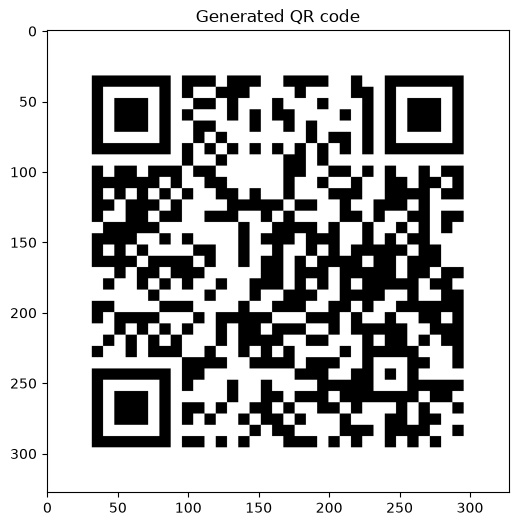

In [2]:
import qrcode

payload = 'https://github.com/AGasthya283/Image-Processing-Techniques'
qr_pil = qrcode.make(payload, box_size=8, border=4).convert('RGB')
qr_img = cv2.cvtColor(np.array(qr_pil), cv2.COLOR_RGB2BGR)
imshow('Generated QR code', qr_img, size=6)

Decoded: 'https://github.com/AGasthya283/Image-Processing-Techniques'
Matches original payload: True


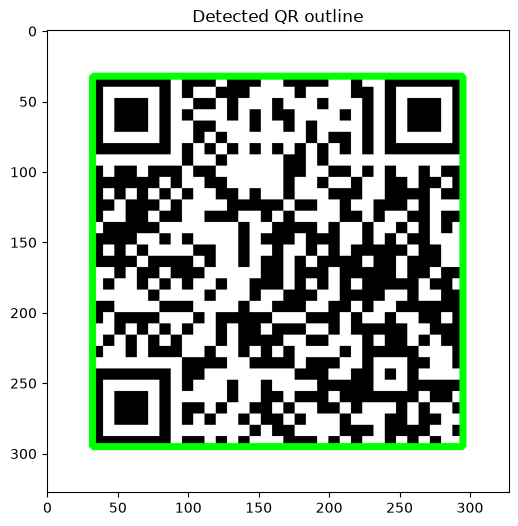

In [3]:
detector = cv2.QRCodeDetector()
data, points, _ = detector.detectAndDecode(qr_img)

print('Decoded:', repr(data))
print('Matches original payload:', data == payload)

located = qr_img.copy()
if points is not None:
    cv2.polylines(located, [np.int32(points)], True, (0, 255, 0), 4)
imshow('Detected QR outline', located, size=6)

## **1D barcodes: EAN-13**

A 1D barcode encodes data purely in the *widths* of alternating bars and gaps — no 2D structure, no error correction the way QR has it, just a checksum digit. That makes it far less redundant than a QR code, and in practice also more sensitive to how it's rendered: `cv2.barcode.BarcodeDetector` is tuned for barcodes as a *camera* actually captures them — with natural anti-aliasing softening each bar edge — not the perfectly crisp, hard-edged bars a vector-graphics library like `python-barcode` renders by default. A pixel-sharp synthetic barcode is *too clean* for it: a tiny Gaussian blur, simulating that real-world softening, is what actually makes detection reliable here — worth comparing sharp vs. blurred directly below.

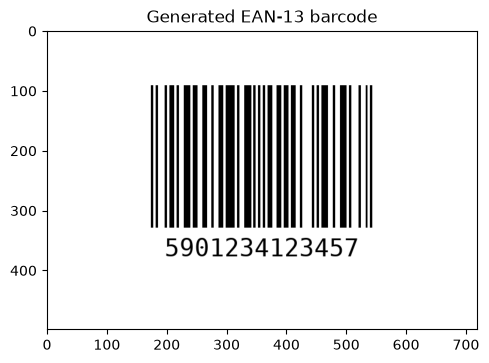

In [4]:
import barcode
from barcode.writer import ImageWriter
from PIL import Image, ImageOps
import io

ean = barcode.get_barcode_class('ean13')('590123412345', writer=ImageWriter())
full_code = ean.get_fullcode()  # the 12 digits we gave it, plus a computed checksum digit

buf = io.BytesIO()
ean.write(buf, options={'module_height': 20, 'quiet_zone': 8})
buf.seek(0)
barcode_pil = ImageOps.expand(Image.open(buf).convert('RGB'), border=80, fill='white')
barcode_sharp = cv2.cvtColor(np.array(barcode_pil), cv2.COLOR_RGB2BGR)
barcode_blurred = cv2.GaussianBlur(barcode_sharp, (3, 3), 0.6)

imshow('Generated EAN-13 barcode', barcode_sharp, size=8)

sharp (as rendered)    -> decoded: ''                 match: False
lightly blurred        -> decoded: '5901234123457'    match: True


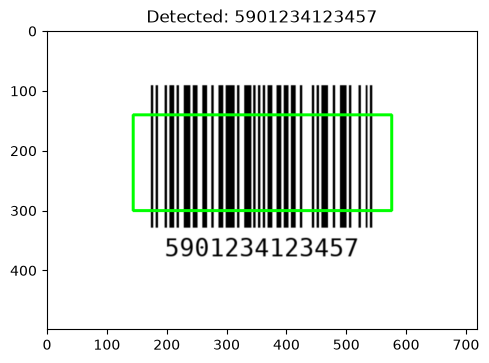

In [5]:
bd = cv2.barcode.BarcodeDetector()

for label, img in [('sharp (as rendered)', barcode_sharp), ('lightly blurred', barcode_blurred)]:
    decoded, points, _ = bd.detectAndDecode(img)
    print(f'{label:22s} -> decoded: {decoded!r:18s} match: {decoded == full_code}')

decoded, points, _ = bd.detectAndDecode(barcode_blurred)
located = barcode_blurred.copy()
if points is not None and len(points):
    cv2.polylines(located, [np.int32(points)], True, (0, 255, 0), 3)
imshow(f'Detected: {decoded}', located, size=8)

### If you want to push this further

- Stamp a small logo (e.g. `assets/images/opencv-logo.png`, resized) over the center of the QR code before decoding — Reed-Solomon error correction should still recover the full payload, up to roughly 30% obscured at the highest correction level (`qrcode.constants.ERROR_CORRECT_H`).
- Sweep the Gaussian blur sigma from 0 to 2.0 on the barcode and plot decode success — there's a narrow sweet spot between "too sharp to read" and "too blurred to read", which says something real about why barcode scanners have a working focal range.
- `cv2.QRCodeDetector` also has `detectAndDecodeMulti` — generate two QR codes side by side in one image and decode both in a single call.